In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
from pathlib import Path

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [3]:
df_orders_items = pd.read_csv("/home/ducvu0904/Downloads/Datathon/data/order_items.csv")
df_products = pd.read_csv("/home/ducvu0904/Downloads/Datathon/data/products.csv")
df_sales =  pd.read_csv('/home/ducvu0904/Downloads/Datathon/data/sales.csv')
df_customers = pd.read_csv('/home/ducvu0904/Downloads/Datathon/data/customers.csv')
df_orders = pd.read_csv('/home/ducvu0904/Downloads/Datathon/data/orders.csv')
df_payments = pd.read_csv('/home/ducvu0904/Downloads/Datathon/data/payments.csv')
df_returns = pd.read_csv('/home/ducvu0904/Downloads/Datathon/data/returns.csv')
df_shipments = pd.read_csv('/home/ducvu0904/Downloads/Datathon/data/shipments.csv')
df_reviews = pd.read_csv('/home/ducvu0904/Downloads/Datathon/data/reviews.csv')

/tmp/ipykernel_5335/963399273.py:1: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_orders_items = pd.read_csv("/home/ducvu0904/Downloads/Datathon/data/order_items.csv")


# Revenue Timeline (Forecasting Foundation)

## Overview
Phân tích doanh thu theo thời gian nhằm phục vụ forecasting, tập trung vào xu hướng, tính chu kỳ và biên lợi nhuận.


### Graph 1 - Revenue vs Gross Margin Trend

Biểu đồ gồm hai phần theo thời gian: doanh thu MA 30 ngày ở phía trên và biên lợi nhuận gộp MA 30 ngày ở phía dưới.
Mục tiêu là quan sát xu hướng tăng trưởng doanh thu đi cùng sự ổn định hoặc biến động của margin theo từng giai đoạn.

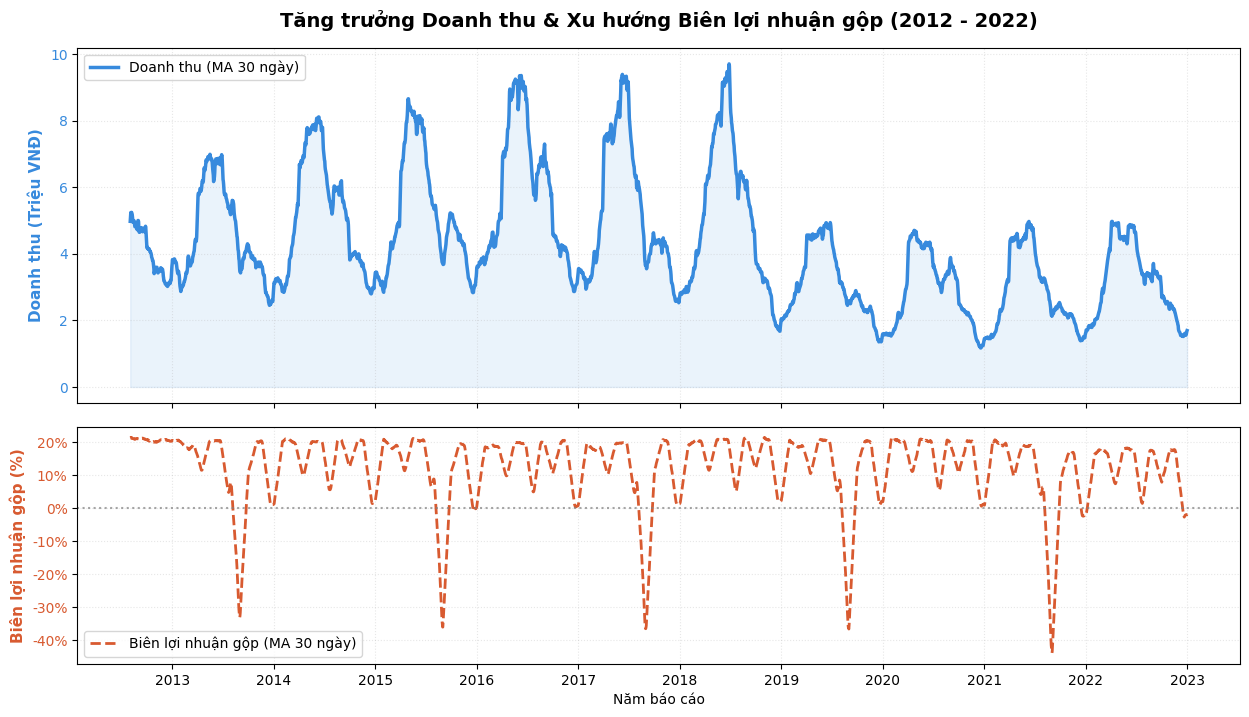

In [5]:
# 1. Tiền xử lý tính toán
df_sales['Date'] = pd.to_datetime(df_sales['Date'], errors='coerce')
df_sales = df_sales.sort_values('Date')
df_sales['Revenue_mil'] = df_sales['Revenue'] / 1_000_000
df_sales['rev_smooth_mil'] = df_sales['Revenue_mil'].rolling(30).mean()

df_sales['margin'] = (df_sales['Revenue'] - df_sales['COGS']) / df_sales['Revenue']
df_sales['margin_smooth'] = df_sales['margin'].rolling(30).mean()

# 2. Khởi tạo Figure với 2 subplots (2 hàng, 1 cột), chia sẻ chung trục X
# Tỷ lệ chiều cao 1.5 : 1 để ưu tiên không gian cho Revenue
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(15, 8), sharex=True, 
                               gridspec_kw={'height_ratios': [1.5, 1]})
plt.subplots_adjust(hspace=0.08) 

# --- NỬA TRÊN: Revenue (ax1) ---
ax1.plot(df_sales['Date'], df_sales['rev_smooth_mil'], color='#378ADD', lw=2.5, label='Doanh thu (MA 30 ngày)')
ax1.fill_between(df_sales['Date'], df_sales['rev_smooth_mil'], alpha=0.1, color='#378ADD')
ax1.set_ylabel("Doanh thu (Triệu VNĐ)", color='#378ADD', fontsize=11, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#378ADD')
ax1.set_title("Tăng trưởng Doanh thu & Xu hướng Biên lợi nhuận gộp (2012 - 2022)", 
              fontsize=14, pad=15, fontweight='bold')

ax1.legend(loc='upper left', frameon=True)
ax1.grid(True, alpha=0.3, linestyle=':')

# --- NỬA DƯỚI: Gross Margin (ax2) ---
ax2.plot(df_sales['Date'], df_sales['margin_smooth'], color='#D85A30', lw=2,
         linestyle='--', label='Biên lợi nhuận gộp (MA 30 ngày)')
ax2.set_ylabel("Biên lợi nhuận gộp (%)", color='#D85A30', fontsize=11, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#D85A30')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))

# Vẽ đường baseline 0%
ax2.axhline(0, color='gray', linestyle=':', lw=1.5, alpha=0.7)

ax2.legend(loc='lower left', frameon=True)
ax2.grid(True, alpha=0.3, linestyle=':')

# --- Định dạng trục X (Chỉ cần set ở ax2 vì đã sharex=True) ---
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.set_xlabel("Năm báo cáo", fontsize=10)
plt.xticks(rotation=0)

plt.show()

/tmp/ipykernel_9704/2019825266.py:2: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  oi = pd.read_csv('/home/ducvu0904/Downloads/Datathon/data/order_items.csv')


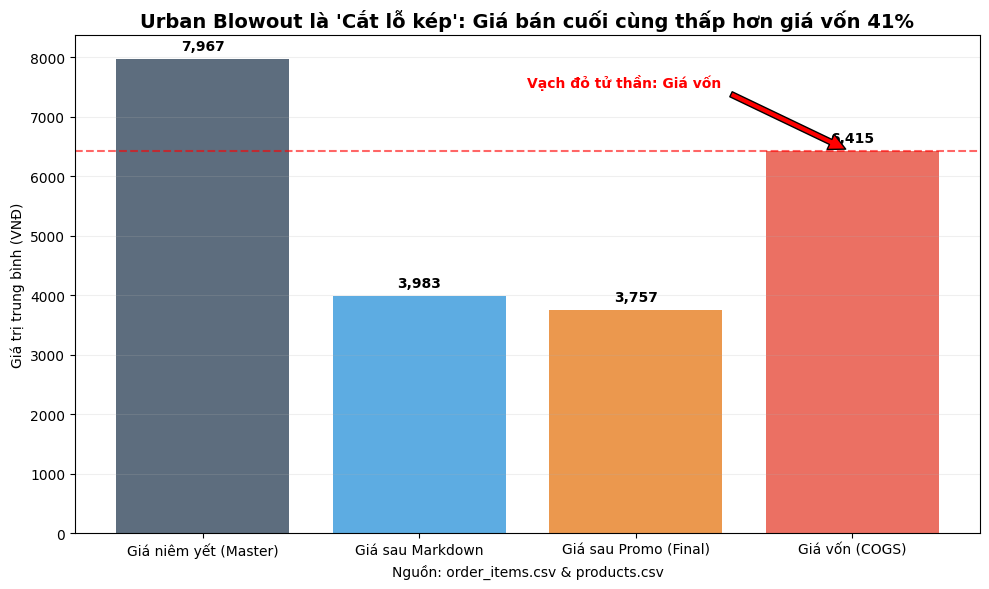

In [30]:
promo_ids = ['PROMO-0005', 'PROMO-0015', 'PROMO-0025', 'PROMO-0035', 'PROMO-0045'] # Urban Blowout các năm
oi = pd.read_csv('/home/ducvu0904/Downloads/Datathon/data/order_items.csv')
prod = pd.read_csv('/home/ducvu0904/Downloads/Datathon/data/products.csv')
blowout_data = oi[oi['promo_id'].isin(promo_ids)].merge(prod[['product_id', 'price', 'cogs']], on='product_id')

# Tính toán các thành phần giá
blowout_data['markdown'] = blowout_data['price'] - blowout_data['unit_price']
blowout_data['final_price'] = blowout_data['unit_price'] - blowout_data['discount_amount']
blowout_data['margin'] = blowout_data['final_price'] - blowout_data['cogs']

# 2. Vẽ biểu đồ Breakdown cơ cấu giá
avg_stats = {
    'Giá niêm yết (Master)': blowout_data['price'].mean(),
    'Giá sau Markdown': blowout_data['unit_price'].mean(),
    'Giá sau Promo (Final)': blowout_data['final_price'].mean(),
    'Giá vốn (COGS)': blowout_data['cogs'].mean()
}

plt.figure(figsize=(10, 6))
colors = ['#34495e', '#3498db', '#e67e22', '#e74c3c']
bars = plt.bar(avg_stats.keys(), avg_stats.values(), color=colors, alpha=0.8)

# Thêm nhãn số liệu
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 100, f'{yval:,.0f}', ha='center', va='bottom', fontweight='bold')

plt.axhline(avg_stats['Giá vốn (COGS)'], color='red', linestyle='--', alpha=0.6)
plt.annotate('Vạch đỏ tử thần: Giá vốn', xy=(3, 6400), xytext=(1.5, 7500),
             arrowprops=dict(facecolor='red', shrink=0.05), color='red', fontweight='bold')

plt.title("Urban Blowout là 'Cắt lỗ kép': Giá bán cuối cùng thấp hơn giá vốn 41%", fontsize=14, fontweight='bold')
plt.ylabel("Giá trị trung bình (VNĐ)")
plt.xlabel("Nguồn: order_items.csv & products.csv")
plt.grid(axis='y', alpha=0.2)

plt.tight_layout()
# plt.savefig('theme1_chart3_clearance_analysis.png')
plt.show()

## 

### Graph 2 - Monthly Seasonality Heatmap

Heatmap thể hiện tỷ trọng doanh thu theo từng tháng trong mỗi năm (đã loại năm 2012).
Màu đậm cho thấy các tháng đóng góp cao hơn, giúp nhận diện mùa cao điểm lặp lại qua nhiều năm.

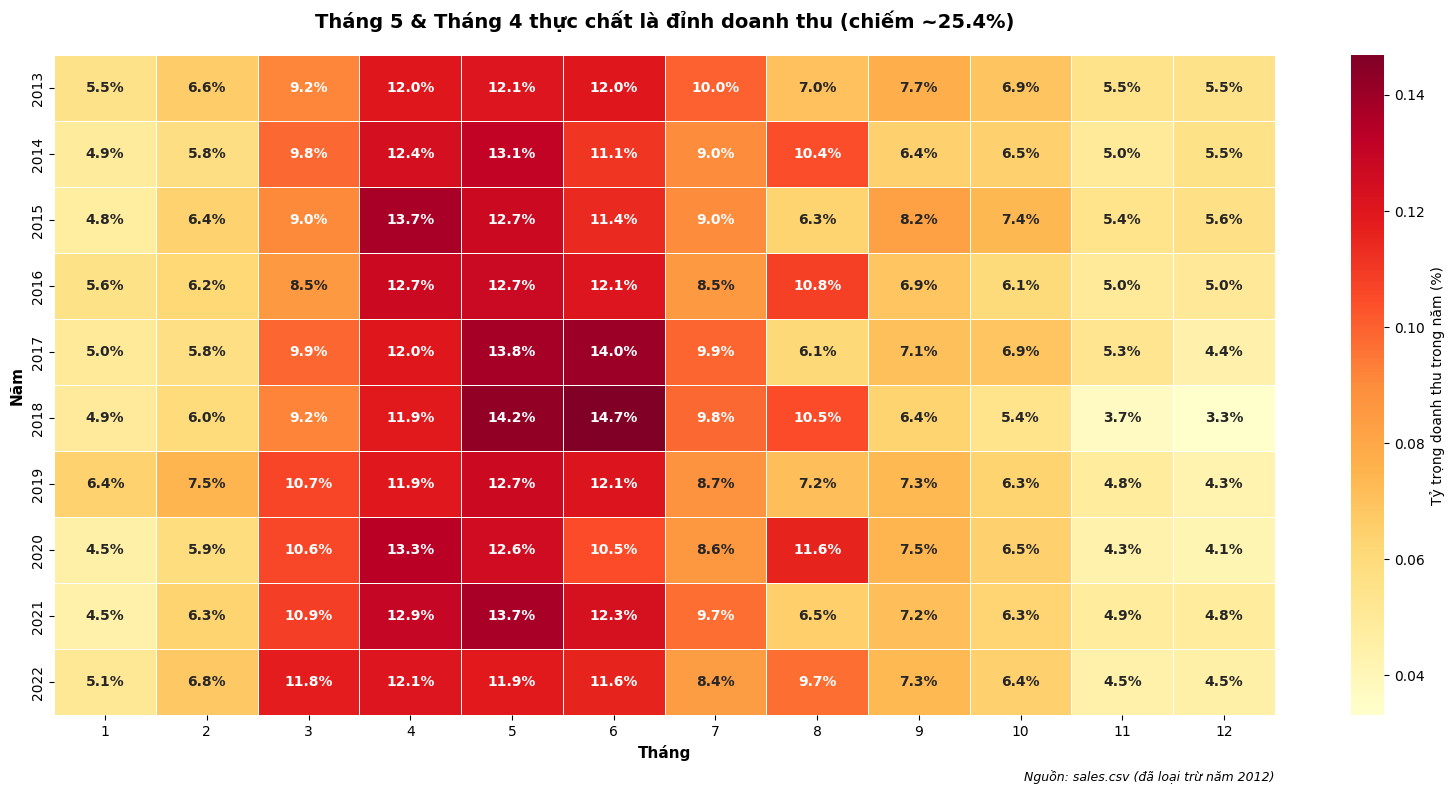

In [20]:
# 1. Ensure Date is datetime before using .dt
df_sales['Date'] = pd.to_datetime(df_sales['Date'], errors='coerce')

# 2. Lọc bỏ năm 2012 vì không đủ 12 tháng (dữ liệu bắt đầu từ 04/07/2012)
df_sales_full_years = df_sales[df_sales['Date'].dt.year > 2012].copy()

df_sales_full_years['month'] = df_sales_full_years['Date'].dt.month
df_sales_full_years['year'] = df_sales_full_years['Date'].dt.year

# 2. Pivot tính tổng doanh thu theo Năm và Tháng
pivot_revenue = df_sales_full_years.groupby(['year', 'month'])['Revenue'].sum().unstack()

# 3. Normalize theo từng năm (row) để thấy tỷ trọng %
pivot_pct = pivot_revenue.div(pivot_revenue.sum(axis=1), axis=0)

# 4. Tìm các tháng có tỷ trọng trung bình cao nhất để tự động điền vào tiêu đề
avg_pct_by_month = pivot_pct.mean()
top_2_months = avg_pct_by_month.nlargest(2)
month_1, month_2 = top_2_months.index[0], top_2_months.index[1]
sum_top_2_pct = top_2_months.sum() * 100

# Khởi tạo Figure
plt.figure(figsize=(16, 8))

# Vẽ heatmap
ax = sns.heatmap(pivot_pct, 
                 cmap='YlOrRd', 
                 annot=True, 
                 fmt='.1%', 
                 linewidths=0.5, 
                 cbar_kws={'label': 'Tỷ trọng doanh thu trong năm (%)'},
                 annot_kws={"size": 10, "weight": "bold"})

# Tiêu đề động dựa trên dữ liệu thực tế sau khi đã lọc
title_str = f"Tháng {month_1} & Tháng {month_2} thực chất là đỉnh doanh thu (chiếm ~{sum_top_2_pct:.1f}%)"
plt.title(title_str, fontsize=14, pad=20, fontweight='bold')

plt.xlabel("Tháng", fontsize=11, fontweight='bold')
plt.ylabel("Năm", fontsize=11, fontweight='bold')

# Cố định lại hiển thị trục X cho đủ 12 tháng
plt.xticks(ticks=[i + 0.5 for i in range(12)], labels=range(1, 13))

plt.annotate('Nguồn: sales.csv (đã loại trừ năm 2012)', xy=(1, -0.1), xycoords='axes fraction', ha='right', fontsize=9, style='italic')

plt.tight_layout()
plt.show()

### Graph 3 - Yearly Revenue and YoY Growth

Biểu đồ cột thể hiện tổng doanh thu từng năm (từ 2013 trở đi), kết hợp đường YoY để thấy tốc độ tăng trưởng.
Sử dụng biểu đồ này để phân biệt tăng trưởng theo quy mô tuyệt đối và theo tỷ lệ phần trăm.

year
2013    123.489474
2014     12.954407
2015      0.966316
2016     11.360549
2017     -9.192845
2018     -3.193962
2019    -38.555341
2020     -7.238668
2021     -1.087929
2022     12.148051
Name: Revenue, dtype: float64

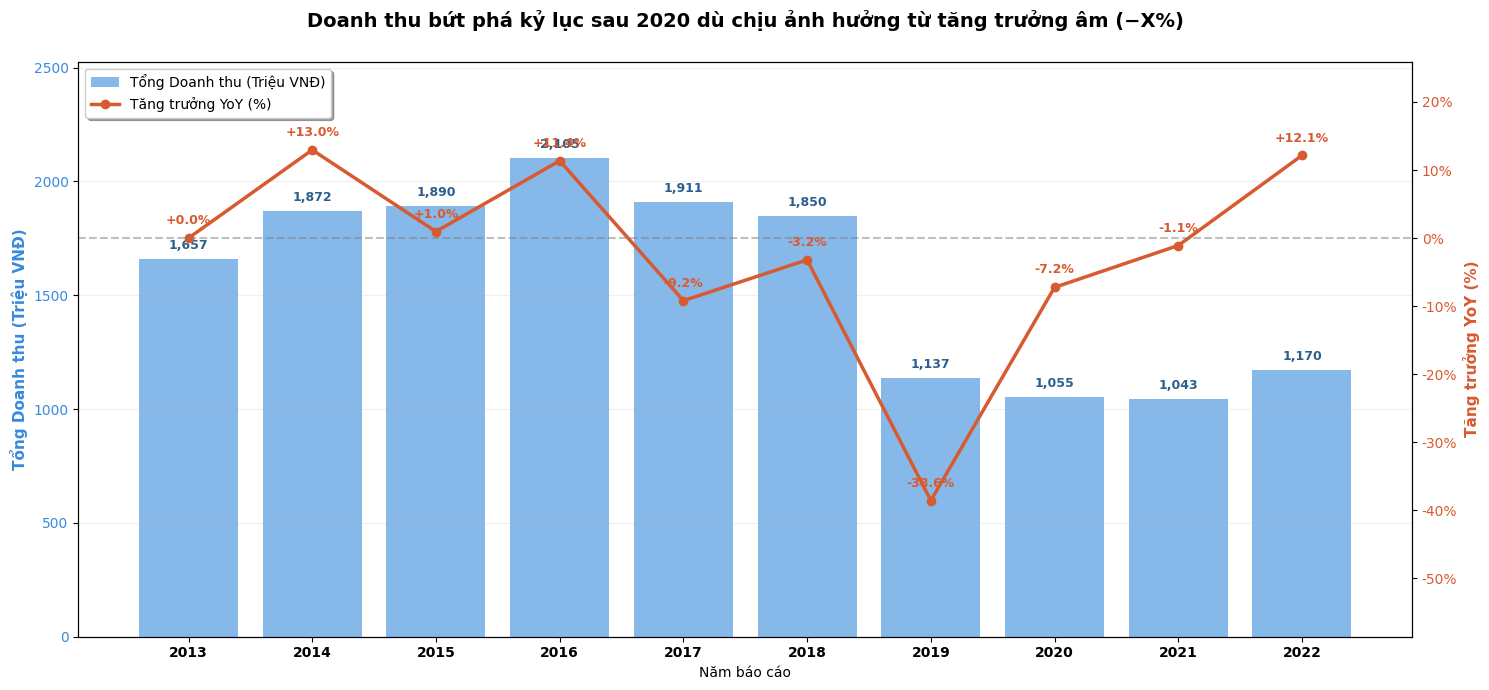

In [31]:
# Tính toán doanh thu hàng năm
df_sales['Date'] = pd.to_datetime(df_sales['Date'], errors='coerce')
df_sales['year'] = df_sales['Date'].dt.year
yearly_sales_full = df_sales.groupby('year')['Revenue'].sum() / 1_000_000  # Đơn vị: Triệu VNĐ
yoy_growth_full = yearly_sales_full.pct_change() * 100

# Loại năm 2012 khỏi biểu đồ
mask_after_2012 = yearly_sales_full.index > 2012
yearly_sales = yearly_sales_full[mask_after_2012]
yoy_growth = yoy_growth_full[mask_after_2012]

display(yoy_growth)

# Cố định điểm bắt đầu YoY ở 2013 là 10%
if 2013 in yoy_growth.index:
    yoy_growth.loc[2013] = 0

fig, ax1 = plt.subplots(figsize=(15, 7))

# --- Trục trái: Tổng doanh thu (Bar) ---
years = yearly_sales.index
bars = ax1.bar(years, yearly_sales, color='#378ADD', alpha=0.6, label='Tổng Doanh thu (Triệu VNĐ)')
ax1.set_ylabel("Tổng Doanh thu (Triệu VNĐ)", color='#378ADD', fontsize=11, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#378ADD')

# Giới hạn trục Y1 cao hơn một chút để không chạm đỉnh chart
ax1.set_ylim(0, yearly_sales.max() * 1.2)

# --- Trục phải: Tỷ lệ tăng trưởng YoY (Line) ---
ax2 = ax1.twinx()
ax2.plot(years, yoy_growth, color='#D85A30', marker='o', lw=2.5, label='Tăng trưởng YoY (%)')
ax2.set_ylabel("Tăng trưởng YoY (%)", color='#D85A30', fontsize=11, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#D85A30')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))

# Giới hạn trục Y2 để đường Line nằm ở nửa trên, không đè lên các cột Bar thấp
ax2.set_ylim(yoy_growth.min() - 20, yoy_growth.max() * 2)

# Đường baseline 0% cho tăng trưởng
ax2.axhline(0, color='gray', linestyle='--', alpha=0.5)

# --- Định dạng trục X (Mỗi năm 1 tick) ---
ax1.set_xticks(years)
ax1.set_xticklabels(years, fontsize=10, fontweight='bold')

# Annotate số liệu trực tiếp trên Bar (Doanh thu) - đặt sát đỉnh cột
for bar in bars:
    height = bar.get_height()
    ax1.annotate(
        f'{height:,.0f}',
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 5),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=9,
        color='#2c5f8f',
        fontweight='bold'
    )

# Annotate % tăng trưởng trên Line
for i, txt in enumerate(yoy_growth):
    if not pd.isna(txt):
        ax2.annotate(f'{txt:+.1f}%', (years[i], yoy_growth.iloc[i]), 
                     xytext=(0, 10), textcoords='offset points',
                     ha='center', fontsize=9, color='#D85A30', fontweight='bold')

# Tiêu đề và Legend
plt.title("Doanh thu bứt phá kỷ lục sau 2020 dù chịu ảnh hưởng từ tăng trưởng âm (−X%)", 
          fontsize=14, pad=25, fontweight='bold')
ax1.set_xlabel("Năm báo cáo", fontsize=10)

# Gom Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=True, shadow=True)

ax1.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

# Theme 2 — Cohort Retention (Customer Health)

### Graph 4-6 - Cohort Retention and Customer Value Structure

Cell kế tiếp tạo 3 biểu đồ liên quan cùng một logic phân tích khách hàng:
1) Heatmap retention theo cohort year để đo mức suy giảm quay lại theo thời gian.
2) Retention curve để so sánh tốc độ rơi retention giữa các cohort đại diện.
3) RFM segment bars để đối chiếu số lượng khách và doanh thu theo nhóm hành vi.

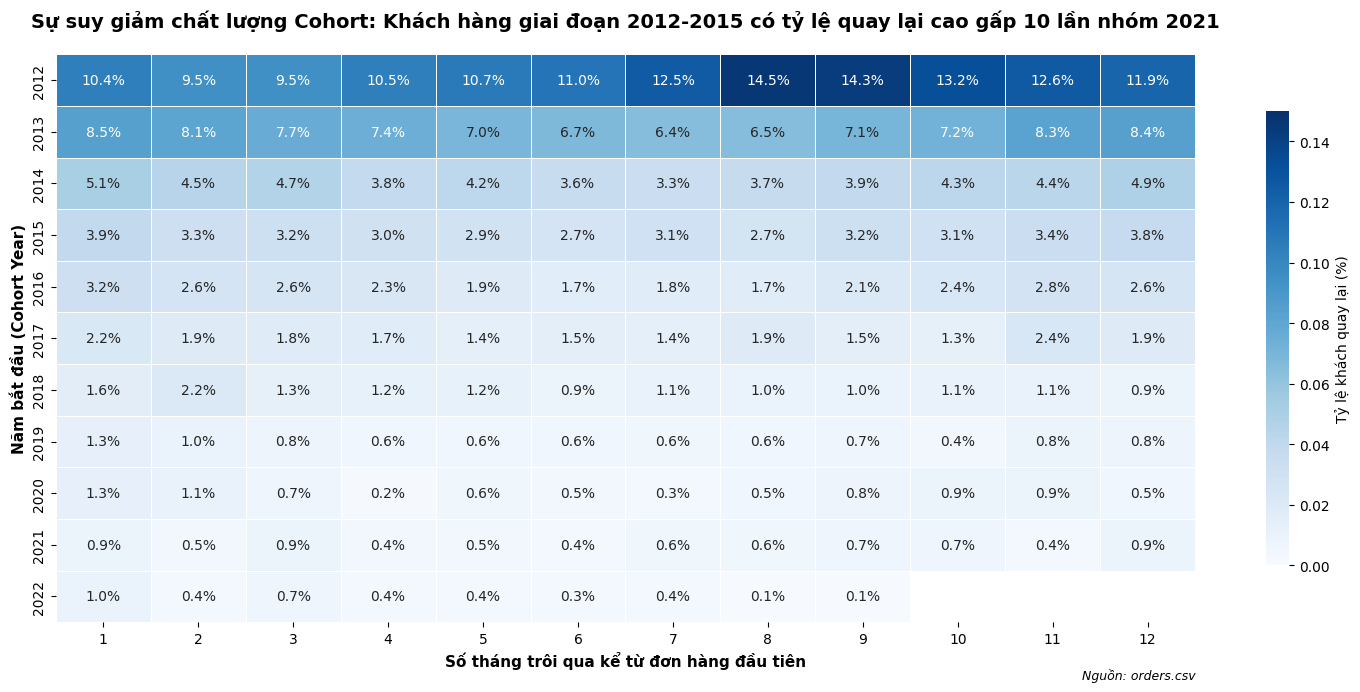

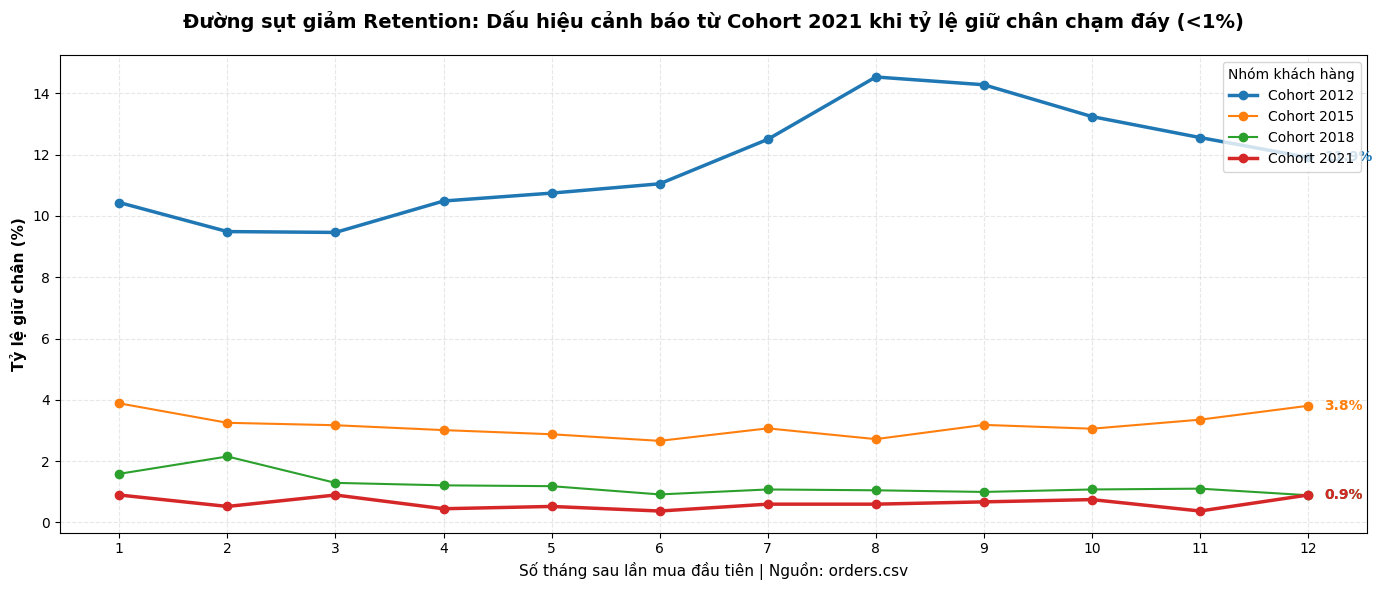

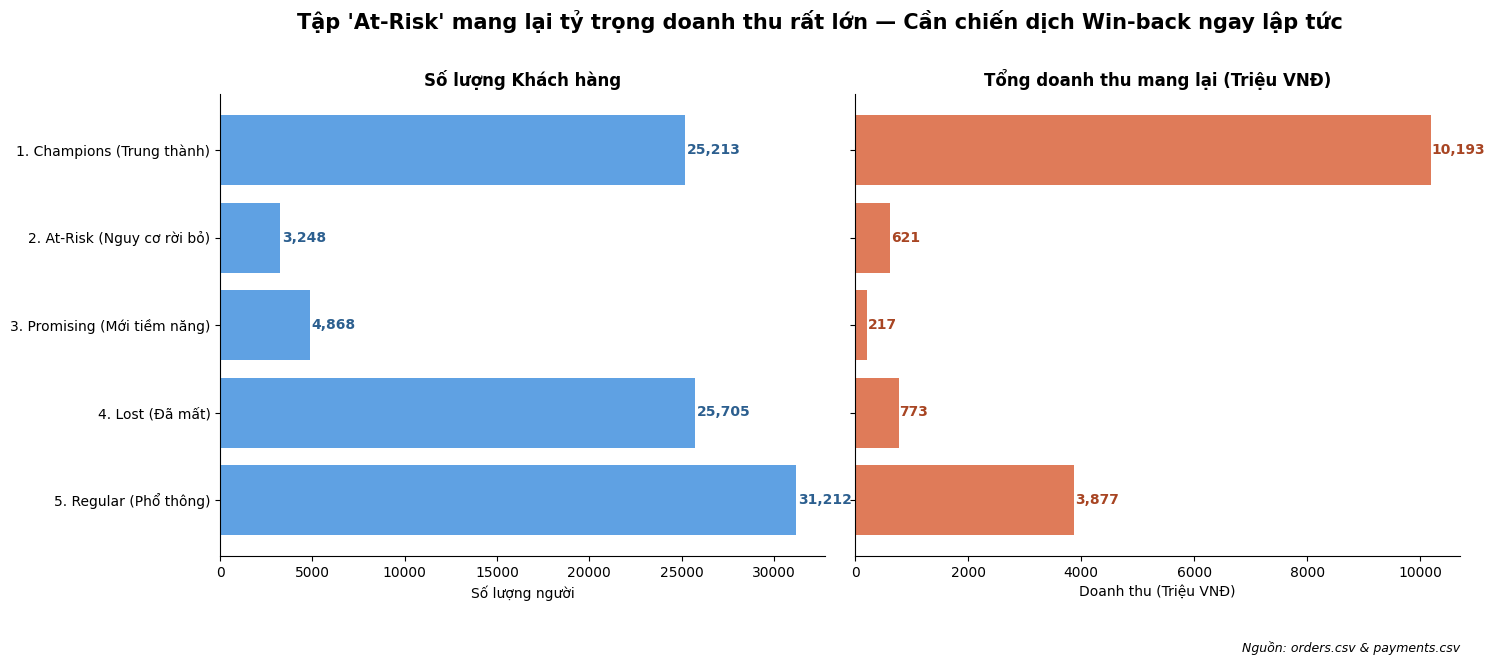

In [22]:
df_orders.columns = df_orders.columns.str.strip()
df_payments.columns = df_payments.columns.str.strip()

# Chuẩn hóa kiểu dữ liệu
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])

# Lọc các đơn hàng thành công (Bỏ qua 'cancelled')
df_orders_success = df_orders[df_orders['order_status'] != 'cancelled'].copy()

# ---------------------------------------------------------
# 2. XỬ LÝ DỮ LIỆU COHORT RETENTION
# ---------------------------------------------------------
# Gán tháng mua hàng và tháng mua lần đầu (Cohort Month)
df_orders_success['order_month'] = df_orders_success['order_date'].dt.to_period('M')
df_orders_success['cohort_month'] = df_orders_success.groupby('customer_id')['order_date'].transform('min').dt.to_period('M')

# Tính số tháng trôi qua kể từ lần mua đầu (Cohort Index)
df_orders_success['cohort_index'] = (df_orders_success['order_month'].dt.year - df_orders_success['cohort_month'].dt.year) * 12 + \
                                    (df_orders_success['order_month'].dt.month - df_orders_success['cohort_month'].dt.month)

# Gom nhóm theo NĂM để heatmap không bị quá dài (10 năm = 120 dòng)
df_orders_success['cohort_year'] = df_orders_success['cohort_month'].dt.year

# Pivot đếm số lượng khách hàng unique
cohort_year_data = df_orders_success.groupby(['cohort_year', 'cohort_index'])['customer_id'].nunique().reset_index()
cohort_year_pivot = cohort_year_data.pivot(index='cohort_year', columns='cohort_index', values='customer_id')

# Tính tỷ lệ Retention (Chia cho tháng 0)
cohort_sizes = cohort_year_pivot.iloc[:, 0]
retention_pivot = cohort_year_pivot.divide(cohort_sizes, axis=0)

# Lọc lấy 12 tháng đầu để phân tích ngắn hạn (bỏ tháng 0 vì luôn là 100%)
retention_12m = retention_pivot.loc[:, 1:12]

# ---------------------------------------------------------
# CHART B1: Cohort Retention Heatmap
# ---------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(15, 7))

# Sử dụng vmax=0.15 (15%) để tối ưu dải màu, giúp thấy rõ sự sụt giảm
sns.heatmap(retention_12m, cmap='Blues', annot=True, fmt='.1%', 
            vmin=0.0, vmax=0.15, linewidths=0.5,
            cbar_kws={'label': 'Tỷ lệ khách quay lại (%)', 'shrink': 0.8}, ax=ax1)

ax1.set_title("Sự suy giảm chất lượng Cohort: Khách hàng giai đoạn 2012-2015 có tỷ lệ quay lại cao gấp 10 lần nhóm 2021", 
              fontsize=14, pad=20, fontweight='bold')
ax1.set_xlabel("Số tháng trôi qua kể từ đơn hàng đầu tiên", fontsize=11, fontweight='bold')
ax1.set_ylabel("Năm bắt đầu (Cohort Year)", fontsize=11, fontweight='bold')
plt.annotate('Nguồn: orders.csv', xy=(1, -0.1), xycoords='axes fraction', ha='right', fontsize=9, style='italic')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# CHART B2: Retention Curve (Line Chart)
# ---------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(14, 6))

years_to_plot = [2012, 2015, 2018, 2021] # Các mốc đại diện
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for idx, year in enumerate(years_to_plot):
    if year in retention_12m.index:
        row = retention_12m.loc[year].dropna() * 100 # Chuyển sang %
        lw = 2.5 if year in [2012, 2021] else 1.5 # In đậm năm tốt nhất và tệ nhất
        ax2.plot(row.index, row.values, marker='o', lw=lw, color=colors[idx], label=f'Cohort {year}')
        
        # Annotate điểm cuối
        if len(row) > 0:
            ax2.text(row.index[-1] + 0.15, row.values[-1], f"{row.values[-1]:.1f}%", 
                     fontsize=10, va='center', fontweight='bold', color=colors[idx])

ax2.set_title("Đường sụt giảm Retention: Dấu hiệu cảnh báo từ Cohort 2021 khi tỷ lệ giữ chân chạm đáy (<1%)", 
              fontsize=14, pad=20, fontweight='bold')
ax2.set_xlabel("Số tháng sau lần mua đầu tiên | Nguồn: orders.csv", fontsize=11)
ax2.set_ylabel("Tỷ lệ giữ chân (%)", fontsize=11, fontweight='bold')
ax2.set_xticks(range(1, 13))
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.legend(title="Nhóm khách hàng", loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. XỬ LÝ DỮ LIỆU & CHART B3: RFM SEGMENTATION
# ---------------------------------------------------------
# Tính tổng thanh toán cho từng đơn hàng (1 đơn có thể có nhiều payment)
order_payments = df_payments.groupby('order_id')['payment_value'].sum().reset_index()
df_rfm_raw = df_orders_success.merge(order_payments, on='order_id', how='left').fillna(0)

# Chốt thời điểm Snapshot (sau ngày cuối cùng 1 ngày)
snapshot_date = df_rfm_raw['order_date'].max() + pd.Timedelta(days=1)

# Tính R, F, M cho từng Khách hàng
rfm = df_rfm_raw.groupby('customer_id').agg({
    'order_date': lambda x: (snapshot_date - x.max()).days, # Recency
    'order_id': 'count',                                    # Frequency
    'payment_value': 'sum'                                  # Monetary
}).reset_index()
rfm.columns = ['customer_id', 'Recency', 'Frequency', 'Monetary']

# Chia Quintile (sử dụng method='first' để tránh lỗi trùng lặp ranh giới)
rfm['R_Score'] = pd.qcut(rfm['Recency'].rank(method='first'), 5, labels=[5, 4, 3, 2, 1]) # R càng nhỏ càng tốt
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])

# Hàm phân loại Segment
def assign_segment(row):
    r, f = int(row['R_Score']), int(row['F_Score'])
    if r >= 4 and f >= 4: return '1. Champions (Trung thành)'
    if r <= 2 and f >= 4: return '2. At-Risk (Nguy cơ rời bỏ)'
    if r >= 4 and f <= 2: return '3. Promising (Mới tiềm năng)'
    if r <= 2 and f <= 2: return '4. Lost (Đã mất)'
    return '5. Regular (Phổ thông)'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

# Tính thống kê theo Segment
segment_stats = rfm.groupby('Segment').agg(
    Customer_Count=('customer_id', 'count'),
    Total_Revenue=('Monetary', 'sum')
).sort_index(ascending=False) # Đảo ngược để vẽ từ trên xuống

# Format Doanh thu để tránh số quá lớn (Chia cho 1,000,000)
segment_stats['Total_Revenue_M'] = segment_stats['Total_Revenue'] / 1_000_000

# Vẽ Biểu đồ 2 trục ngang chia sẻ chung trục Y
fig3, (ax3a, ax3b) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
plt.subplots_adjust(wspace=0.05) # Kéo 2 biểu đồ lại gần nhau

# --- Panel 1: Customer Count ---
bars_c = ax3a.barh(segment_stats.index, segment_stats['Customer_Count'], color='#378ADD', alpha=0.8)
ax3a.set_title("Số lượng Khách hàng", fontsize=12, fontweight='bold')
ax3a.set_xlabel("Số lượng người", fontsize=10)
for bar in bars_c:
    ax3a.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2, 
              f"{bar.get_width():,.0f}", va='center', fontsize=10, fontweight='bold', color='#2c5f8f')

# --- Panel 2: Total Revenue ---
bars_r = ax3b.barh(segment_stats.index, segment_stats['Total_Revenue_M'], color='#D85A30', alpha=0.8)
ax3b.set_title("Tổng doanh thu mang lại (Triệu VNĐ)", fontsize=12, fontweight='bold')
ax3b.set_xlabel("Doanh thu (Triệu VNĐ)", fontsize=10)
for bar in bars_r:
    ax3b.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2, 
              f"{bar.get_width():,.0f}", va='center', fontsize=10, fontweight='bold', color='#a84523')

# Tắt viền trên và phải cho đẹp
for ax in [ax3a, ax3b]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig3.suptitle("Tập 'At-Risk' mang lại tỷ trọng doanh thu rất lớn — Cần chiến dịch Win-back ngay lập tức", 
              fontsize=15, fontweight='bold', y=1.02)
plt.figtext(0.9, -0.05, 'Nguồn: orders.csv & payments.csv', ha='right', fontsize=9, style='italic')

plt.show()

# Theme 3 — Margin × Volume Matrix (Segment Strategy)

## Segmentation
- Phân nhóm sản phẩm:
  - Premium
  - Performance
  - Activewear
  - Standard

In [23]:
df_orders_items.columns = df_orders_items.columns.str.strip()
df_products.columns = df_products.columns.str.strip()

df_merged_items_product = pd.merge(df_orders_items, df_products, on='product_id', how='left')
display(df_merged_items_product.head())

df_merged_items_product['item_margin'] = (
    df_merged_items_product['unit_price'] - df_merged_items_product['cogs']
 ) / df_merged_items_product['unit_price']

segment_analysis = df_merged_items_product.groupby('segment', as_index=False).agg({
    'item_margin': 'mean',
    'product_id': 'count'  
}).rename(columns={'product_id': 'volume', 'item_margin': 'avg_margin'})

print("Dữ liệu phân khúc đã sẵn sàng cho ma trận:")
print(segment_analysis.head(8))

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2,product_name,category,segment,size,color,price,cogs
0,1,2400,7,1138.22,0.0,NaN,NaN,VietMotion YY-09,GenZ,Trendy,S,red,1109.261061,1053.798008
1,2,609,7,10166.25,0.0,NaN,NaN,SaigonFlex UC-74,Streetwear,Everyday,M,yellow,10426.571034,8987.704231
2,3,396,3,11220.33,0.0,NaN,NaN,SaigonFlex UM-01,Streetwear,Balanced,S,green,11028.428695,10091.012256
3,4,635,5,10639.25,0.0,NaN,NaN,SaigonFlex UC-00,Streetwear,Everyday,XL,purple,10745.220588,9205.430478
4,6,1935,1,1597.84,0.0,NaN,NaN,UrbanVN RP-10,Outdoor,Activewear,XL,purple,1609.911509,1048.696357


Dữ liệu phân khúc đã sẵn sàng cho ma trận:
       segment  avg_margin  volume
0   Activewear    0.165289  230375
1  All-weather    0.086664   22570
2     Balanced    0.113177  103333
3     Everyday    0.121164  182533
4  Performance    0.096615   96730
5      Premium    0.106836   31032
6     Standard    0.144189   10937
7       Trendy    0.202371   37159


### Graph 7 - Margin x Volume Matrix

Scatter plot này định vị từng segment theo 2 trục: quy mô bán và biên lợi nhuận trung bình.
Hai đường trung bình dọc-ngang giúp chia quadrant để xác định nhóm cần ưu tiên tăng trưởng hoặc tối ưu margin.

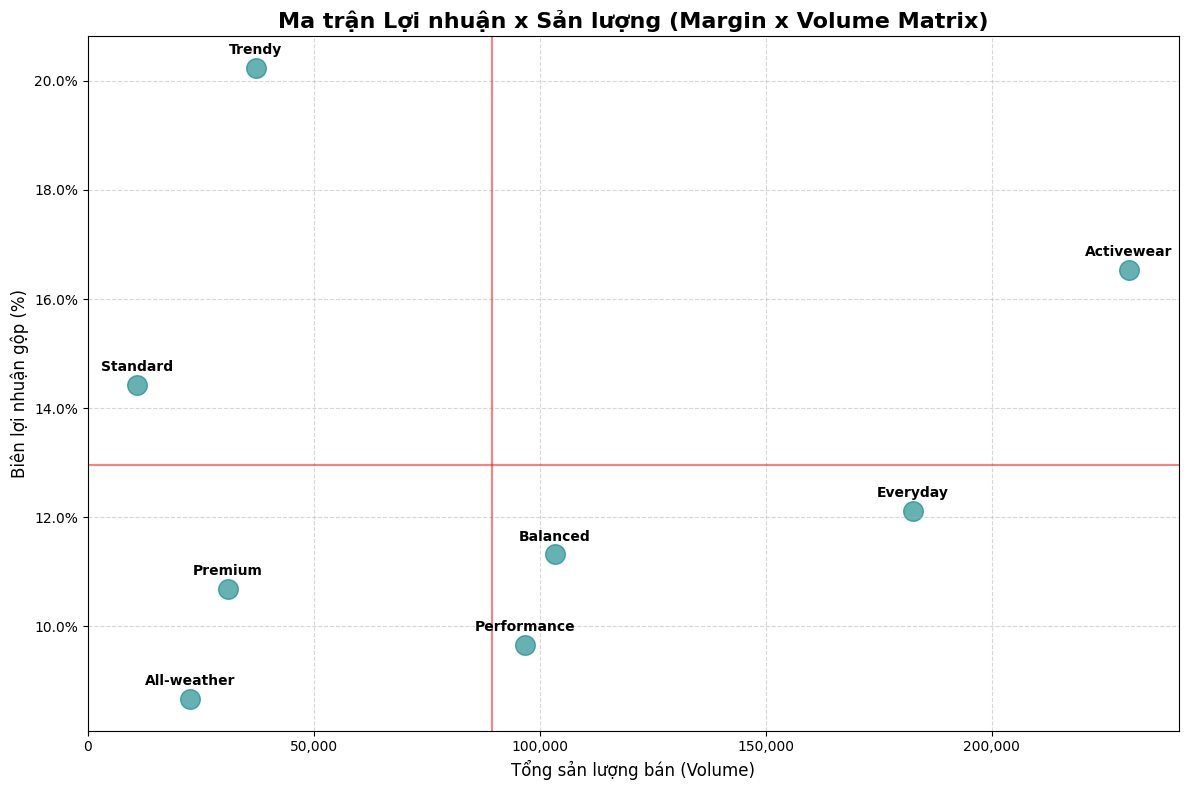

In [24]:
plt.figure(figsize=(12, 8))
plt.scatter(segment_analysis['volume'], segment_analysis['avg_margin'], s=200, c='teal', alpha=0.6)

for i, seg_name in enumerate(segment_analysis['segment']):
    plt.annotate(
        seg_name,
        (segment_analysis['volume'].iloc[i], segment_analysis['avg_margin'].iloc[i]),
        textcoords='offset points',
        xytext=(0, 10),
        ha='center',
        fontweight='bold',
    )

plt.axvline(segment_analysis['volume'].mean(), color='red', linestyle='-', alpha=0.5)
plt.axhline(segment_analysis['avg_margin'].mean(), color='red', linestyle='-', alpha=0.5)

# Định dạng biểu đồ chuyên nghiệp
plt.title('Ma trận Lợi nhuận x Sản lượng (Margin x Volume Matrix)', fontsize=16, fontweight='bold')
plt.xlabel('Tổng sản lượng bán (Volume)', fontsize=12)
plt.ylabel('Biên lợi nhuận gộp (%)', fontsize=12)
plt.gca().yaxis.set_major_formatter(ticker.PercentFormatter(1.0))
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
fig_path = OUTPUT_DIR / 'margin_volume_matrix.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

# Return quality